In [15]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [16]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [17]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (171772476547)>


In [18]:
# step_rectangle_trapezoid_fragment_fixed.py
import gmsh

# --- Initialize Gmsh ---
gmsh.initialize()
gmsh.model.add("rectangle_trapezoid_fragment")
occ = gmsh.model.occ

# --- Geometry ---
rect1 = occ.addRectangle(0, 0, 0, 40, 5)
rect2 = occ.addRectangle(40, 0, 0, 20, 5)

p1 = occ.addPoint(0, 5, 0)
p2 = occ.addPoint(40, 5, 0)
p3 = occ.addPoint(20, 15, 0)
p4 = occ.addPoint(0, 15, 0)

l1 = occ.addLine(p1, p2)
l2 = occ.addLine(p2, p3)
l3 = occ.addLine(p3, p4)
l4 = occ.addLine(p4, p1)

trap_loop = occ.addCurveLoop([l1, l2, l3, l4])
trap_surf = occ.addPlaneSurface([trap_loop])

occ.synchronize()

# --- Fragment all together ---
occ.fragment([(2, rect1), (2, rect2)], [(2, trap_surf)])
occ.removeAllDuplicates()
occ.synchronize()

# --- Get surface tags ---
surfs = [tag for dim, tag in gmsh.model.getEntities(2)]

# --- Transfinite mesh: surface 1 ---
gmsh.model.mesh.setTransfiniteCurve(1, 20)
gmsh.model.mesh.setTransfiniteCurve(2, 5)
gmsh.model.mesh.setTransfiniteCurve(3, 20)
gmsh.model.mesh.setTransfiniteCurve(4, 5)
gmsh.model.mesh.setTransfiniteSurface(surfs[0])
gmsh.model.mesh.setRecombine(2, surfs[0])

# --- Transfinite mesh: surface 2 ---
#gmsh.model.mesh.setTransfiniteCurve(2, 5)
gmsh.model.mesh.setTransfiniteCurve(5, 10)
gmsh.model.mesh.setTransfiniteCurve(6, 5)
gmsh.model.mesh.setTransfiniteCurve(7, 10)
gmsh.model.mesh.setTransfiniteSurface(surfs[1])
gmsh.model.mesh.setRecombine(2, surfs[1])

# --- Transfinite mesh: surface 3 ---
#gmsh.model.mesh.setTransfiniteCurve(3, 10)
gmsh.model.mesh.setTransfiniteCurve(8, 20)
gmsh.model.mesh.setTransfiniteCurve(9, 20)
gmsh.model.mesh.setTransfiniteCurve(10, 20)
gmsh.model.mesh.setTransfiniteSurface(surfs[2])
gmsh.model.mesh.setRecombine(2, surfs[2])

#p5 = occ.addPoint(4.21, 15.249, 0)
#p6 = occ.addPoint(15.78, 15.249, 0)
#l5 = occ.addLine(p5, p6)
#gmsh.model.occ.synchronize()
#gmsh.model.mesh.setTransfiniteCurve(11, 12)

# --- Physical lines ---
# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support_a")

gmsh.model.addPhysicalGroup(1, [5], tag=202)
gmsh.model.setPhysicalName(1, 202, "bottom_support_b")

gmsh.model.addPhysicalGroup(1, [4], tag=203)
gmsh.model.setPhysicalName(1, 203, "left_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=204)
gmsh.model.setPhysicalName(1, 204, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [10], tag=205)
gmsh.model.setPhysicalName(1, 205, "left_top_support")

gmsh.model.addPhysicalGroup(1, [9], tag=206)
gmsh.model.setPhysicalName(1, 206, "loadings")

gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot_a")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_bot_b")

gmsh.model.addPhysicalGroup(2, [3], 303)
gmsh.model.setPhysicalName(2, 303, "soil_top")

gmsh.model.addPhysicalGroup(1, [11], tag=304)
gmsh.model.setPhysicalName(1, 304, "beam")

# Get coordinates for a specific node ID
#node_tag = 137  # replace with your actual node tag
#node_coords = gmsh.model.mesh.getNode(node_tag)[0]  # returns (x, y, z)
#print(f"Node {node_tag} coordinates: {node_coords}")

# --- Finalize mesh ---
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("slope_stability_sspquaup.msh")
#gmsh.fltk.run()
#gmsh.finalize()

In [19]:
GMSH2OPS = opst.pre.Gmsh2OPS(ndm=2, ndf=2)
GMSH2OPS.read_gmsh_file("slope_stability_sspquaup.msh")
gmsh.finalize()

Info:: 10 Physical Names.
Info:: 525 Nodes; MaxNodeTag 525; MinNodeTag 1.
Info:: 547 Elements; MaxEleTag 547; MinEleTag 1.
Info:: Geometry Information >>>
21 Entities: 8 Point; 10 Curves; 3 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
9 Physical Groups.
Physical Group names: ['bottom_support_a', 'left_bot_support', 'bottom_support_b', 'right_bot_support', 'loadings', 'left_top_support', 'soil_bot_a', 'soil_bot_b', 'soil_top']

Info:: Mesh Information >>>
525 Nodes; MaxNodeTag 525; MinNodeTag 1.
547 Elements; MaxEleTag 547; MinEleTag 1.



In [20]:
GMSH2OPS.get_physical_groups()

{'bottom_support_a': [(1, 1)],
 'left_bot_support': [(1, 4)],
 'bottom_support_b': [(1, 5)],
 'right_bot_support': [(1, 6)],
 'loadings': [(1, 9)],
 'left_top_support': [(1, 10)],
 'soil_bot_a': [(2, 1)],
 'soil_bot_b': [(2, 2)],
 'soil_top': [(2, 3)]}

In [21]:
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 3)

In [22]:
fmass = 1.0  # fluid mass density
smass = 2.0  # saturated soil mass density
G = 6.0e4
B = 2.4e5
bulk = 2.2e6  # fluid-solid combined bulk modulus
vperm = 5.0e-4  # vertical permeability (m/s)
hperm = 5.0e-4  # horizontal permeability (m/s)
accGravity = 9.81  # acceleration of gravity

# Actual values used in computation
vperm = vperm / accGravity / fmass
hperm = hperm / accGravity / fmass

press = 0.0  # isotropic consolidation pressure on quad element(s)
loadBias = 0.07  # Static shear load, in percentage of gravity load

accMul = 2.0  # acc. multiplier
accNam = "whatever.acc"  # file name for input acc. record
accDt = 0.0166  # dt of input acc. record
period = 1.0  # Period for applied Sine wave
deltaT = 0.01  # time step for analysis
numSteps = 2400  # number of time steps
gamma = 0.6  # Newmark integration parameter

massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.002

numXele = 1  # number of elements in x (H) direction
numYele = 10  # number of elements in y (V) direction
xSize = 1.0  # x direction element size
ySize = 1.0  # y direction element size

fos = 1.5
refshearModul = 6e4
rho = 1.8
refbulk = 3e5
frictionAngle = 30 / fos
cohesion = 30
peakShearStrain = 0.1
refPressure = 0
pressDependent = 0
noYieldSurf = 20

gravY = -accGravity  # calc. gravity
gravX = -gravY * loadBias

soil_mattag = 1
nd_soilmat = 5

In [23]:
ops.nDMaterial("PressureDependMultiYield", nd_soilmat, 2, smass, G, B, frictionAngle, 0.1, 80, 0.5, 26.5, 0.1, 0.2, 5, 10, 0.015, 1.0)
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mattag, nd_soilmat, 2)

Will set phaseTransformAng = frictionAng.
InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [24]:
GMSH2OPS.create_node_cmds()
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"
rho_d = 0.0

soil_groups = [
    "soil_bot_a",
    "soil_bot_b",
    "soil_top"
]
#               thick,
element_args = [ 1.0, soil_mattag, bulk, fmass, hperm, vperm, gravX, gravY, press] # press, rho_d, unitWeightX, unitWeightY

# Create elements for each soil group
for group_name in soil_groups:
    ele_tags = GMSH2OPS.create_element_cmds(
        ops_ele_type="quadUP",
        ops_ele_args=element_args,
        physical_group_names=[group_name]
    )

In [25]:
node_id = 7
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")
node_id = 97
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")

Node 7 coordinate: [20.0, 15.0]
Node 97 coordinate: [9.473684210526317, 15.0]


In [26]:
ops.model("basic", "-ndm", 2, "-ndf", 3)
start_N_id = SF.get_next_node_id(start_from=None)

In [27]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [28]:
pad_foundation_coor = [
[20.0000 , 15.0000],
[18.9474 , 15.0000],
[17.8947 , 15.0000],
[16.8421 , 15.0000],
[15.7895 , 15.0000],
[14.7368 , 15.0000],
[13.6842 , 15.0000],
[12.6316 , 15.0000],
[11.5789 , 15.0000],
[10.5263 , 15.0000],
[ 9.4737 , 15.0000],
]

pad_noodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation_coor, start_id = start_N_id, block_name = "pad_nodes")

In [29]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.3)
print(Iz)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAMs = SF.create_disp_beam_column_chain(beam_nodes = pad_noodes, beam_start_id = 1001,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain")

0.00225


In [30]:
print(BEAMs)
lining_slave_nodes = [7,88, 89, 90, 91, 92, 93, 94,95 ,96, 97]

[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]


In [31]:
pad_soil = SF.apply_equal_dof_pairs(r_nodes = pad_noodes, c_nodes = lining_slave_nodes , dofs=[1, 2], block_name="equal_dof_pairs")

In [32]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [33]:
fixXY = [1, 1, 1]
fixXonly = [1, 0, 0]
fixYonly = [0, 1, 0]

In [34]:
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_a"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_b"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_bot_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_top_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["right_bot_support"], dofs=fixXonly)
ops.fix(4, *fixXonly)
ops.fix(8, *fixXonly)
ops.fix(6, *fixXonly)
ops.fix(1, *fixXY)
ops.fix(2, *fixXY)
ops.fix(5, *fixXY)

In [35]:
import openseespy.opensees as ops
import opstool as opst
import opstool.vis.plotly as opsvis

In [36]:
print("=== Gravity analysis start ===")

# Enable initial state analysis (soil model reads initial stresses)
ops.InitialStateAnalysis("on")

# --- Elastic stage ---
ops.updateMaterialStage("-material", soil_mattag, "-stage", 0)
print("Material set to elastic for gravity loading")

# Analysis options for elastic stage
ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("UmfPack")  # more robust for unsymmetric matrices
ops.test("NormDispIncr", 1e-8, 30, 0)
ops.algorithm("NewtonLineSearch")  # smoother convergence than plain Newton
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4) #ops.integrator("HHT", 0.10) # mild numerical damping
ops.analysis("Transient")

# Elastic gravity loading
ops.analyze(10, 5.0e3)
print("Elastic gravity analysis complete")

# --- Plastic stage ---
ops.updateMaterialStage("-material", soil_mattag, "-stage", 1)
print("Material set to plastic for gravity loading")

# Continue with same settings or adjust if needed
#ops.analyze(40, 500.0)
print("Plastic gravity analysis complete")

# Turn off initial state analysis
ops.InitialStateAnalysis("off")

print("=== Gravity analysis finished ===")

=== Gravity analysis start ===
Material set to elastic for gravity loading
Elastic gravity analysis complete
Material set to plastic for gravity loading
Plastic gravity analysis complete
=== Gravity analysis finished ===


InitialStateAnalysis ON
InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [ ]:
ops.wipeAnalysis()
ops.setTime(0.0)

ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
for bb in BEAMs:
    opst.pre.transform_beam_uniform_load(bb, wy=-30.0)

opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = True, show_ele_loads=True)

: 

In [ ]:


ops.recorder('Element', '-ele', 187, '-file', '187_backbone.out', '-dT', 0.01, 'material', 1, 'backbone',0.1, 0.2)
ops.recorder('Element', '-ele', 306, '-file', '306_backbone.out', '-dT', 0.01, 'material', 1, 'backbone',0.1, 0.2)
ops.recorder('Element', '-ele', 242, '-file', '242_backbone.out', '-dT', 0.01, 'material', 1, 'backbone', 0.1, 0.2)

# DYNAMIC ANALYSIS
ops.constraints("Transformation") 
ops.numberer("RCM")
ops.system("UmfPack") 
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4)
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
#ops.analysis("VariableTransient")

startT = tt.time()

ODB = opst.post.CreateODB(odb_tag="Slope_quadup_ab") 
analysis = opst.anlys.SmartAnalyze(
    analysis= "Transient",
    testType= "NormDispIncr",
    testTol= 1.0e-8,
    testIterTimes= 25,
    testPrintFlag= 0,
    tryAddTestTimes= True,
    normTol= 1000,
    testIterTimesMore= [50],
    tryLooseTestTol= True,
    looseTestTolTo= 1e-3,
    tryAlterAlgoTypes= True,
    algoTypes= [20],#40, 30, 60
    UserAlgoArgs= None,
    initialStep= None,
    relaxation= 0.5,
    minStep= 1.0e-6,
    debugMode= False,
    printPer= 20,
)

npts, dt = 1000, 0.01
segs = analysis.transient_split(npts)
for seg in segs:
    analysis.TransientAnalyze(dt)
    ODB.fetch_response_step()

ODB.save_response(zlib=True)

endT = tt.time()
print(f"Execution time: {endT - startT} seconds")
# Wipe model
ops.wipe()

Output()

🎉 SmartAnalyze: Successfully finished! Time consumption: 460.561 s. 🎉

In [1]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis
import numpy as np

In [2]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_quadup_ab.nc ...

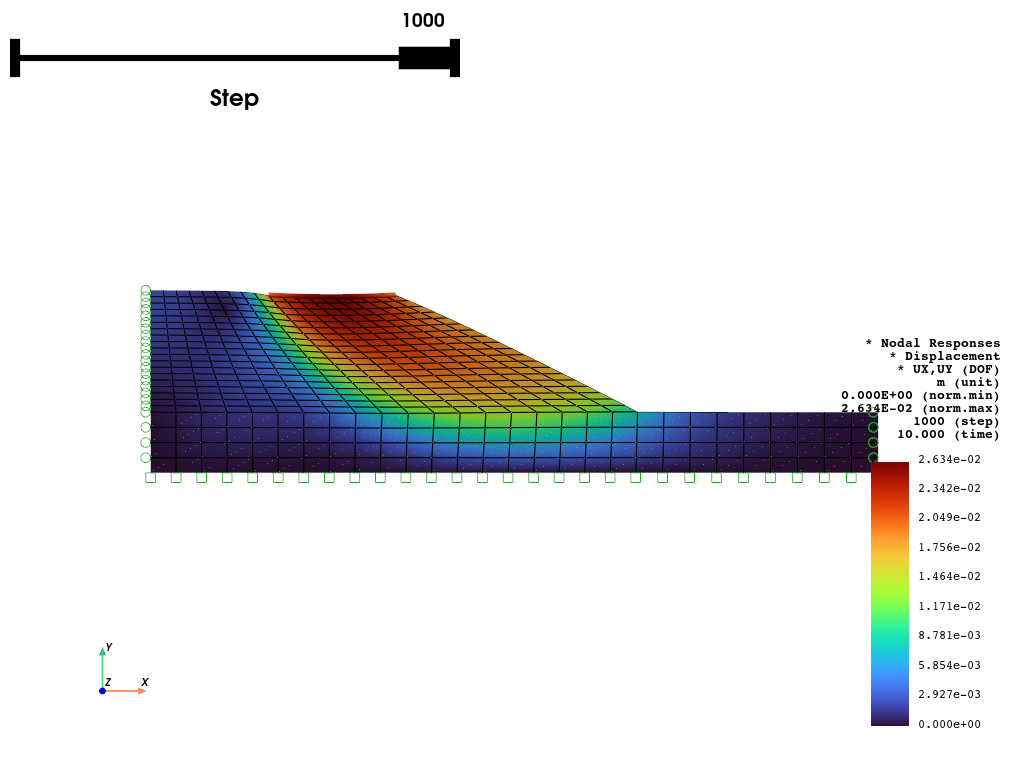

In [3]:
opsvis.plot_nodal_responses(
    odb_tag="Slope_quadup_ab",
    slides=True,
    defo_scale=20,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_quadup_ab.nc ...

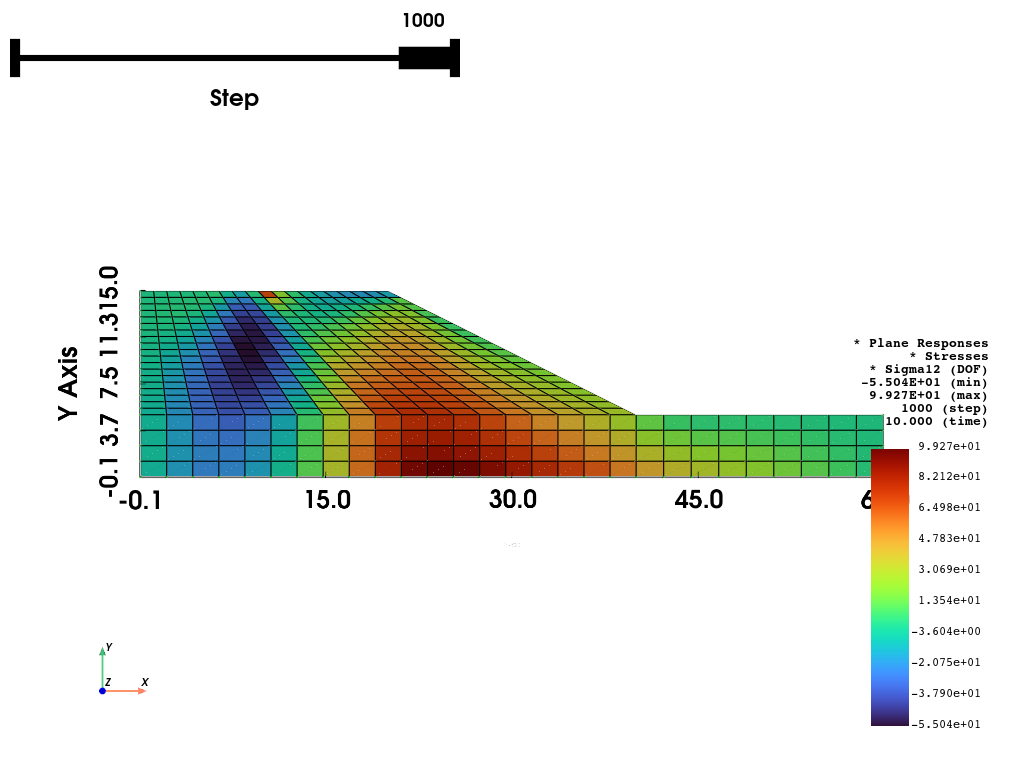

In [4]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="Slope_quadup_ab", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab")

In [5]:
ele_resp = opst.post.get_element_responses(odb_tag="Slope_quadup_ab", ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-Slope_quadup_ab.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 38MB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 23MB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 11MB -176.8 ....
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 6MB 6.269e-06...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 11MB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 6MB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 30MB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 30MB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 8MB -176.8 ... ...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 8MB 6.386e-06 ....


In [6]:
print(ele_resp.stressDOFs.data)
print(ele_resp.strainDOFs.data)
print(ele_resp.measures.data)

['sigma11' 'sigma22' 'sigma12' 'sigma33' 'eta_r']
['eps11' 'eps22' 'eps12']
['p1' 'p2' 'sigma_vm' 'tau_max']


In [7]:
ele_check = 154

In [8]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=ele_check)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=ele_check)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=ele_check)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=ele_check)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=ele_check)


In [9]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 4)> Size: 16kB
array([[ 7.3233566,  7.352525 ,  7.32594  ,  7.295188 ],
       [ 6.999603 ,  6.9835453,  7.0368514,  7.050609 ],
       [ 7.2044754,  7.1544075,  7.257202 ,  7.3041687],
       ...,
       [15.129676 , 20.16832  , 36.468277 , 30.26238  ],
       [15.125305 , 20.17283  , 36.506187 , 30.282066 ],
       [15.120863 , 20.177315 , 36.544197 , 30.30175  ]],
      shape=(1001, 4), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.97 9.98 9.99 10.0
    eleTags      int64 8B 154
  * GaussPoints  (GaussPoints) int64 32B 1 2 3 4
    stressDOFs   <U7 28B 'sigma12'


In [10]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=ele_check)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=ele_check)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=ele_check)

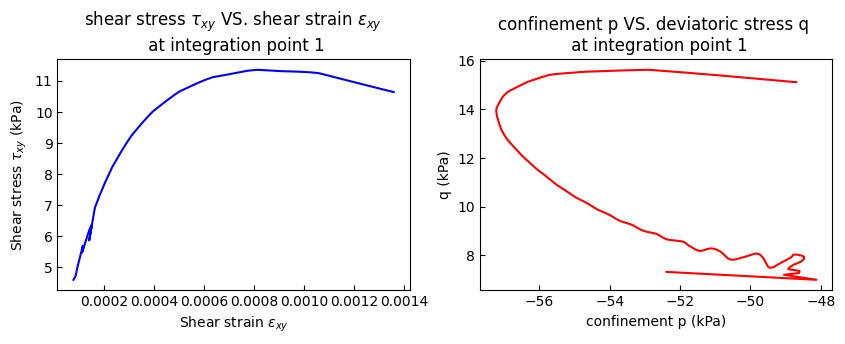

In [11]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [12]:
node_resp = opst.post.get_nodal_responses(odb_tag="Slope_quadup_ab")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-Slope_quadup_ab.nc ...

<xarray.Dataset> Size: 79MB
Dimensions:             (time: 1001, nodeTags: 536, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.98 9.99 10.0
  * nodeTags            (nodeTags) int64 4kB 1 2 3 4 5 6 ... 532 533 534 535 536
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 13MB 0.0 ... -0.002217
    vel                 (time, nodeTags, DOFs) float32 13MB 0.0 ... -0.000222
    accel               (time, nodeTags, DOFs) float32 13MB 0.0 ... -0.0001116
    reaction            (time, nodeTags, DOFs) float32 13MB 108.0 ... 0.00554
    reactionIncInertia  (time, nodeTags, DOFs) float32 13MB 108.0 ... -7.163e-12
    rayleighForces      (time, nodeTags, DOFs) float32 13MB 0.0 0.0 ... -0.00554
    pressure            (time, nodeTags) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction

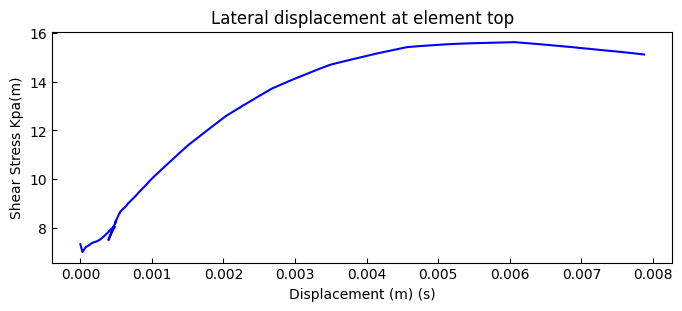

In [13]:
disp1 = node_resp["disp"].sel(nodeTags=30, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(disp3 ,qo_ele1_1, "b") #- disp1 times, 
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Displacement (m) (s)")
ax.set_ylabel("Shear Stress Kpa(m)")
plt.show()

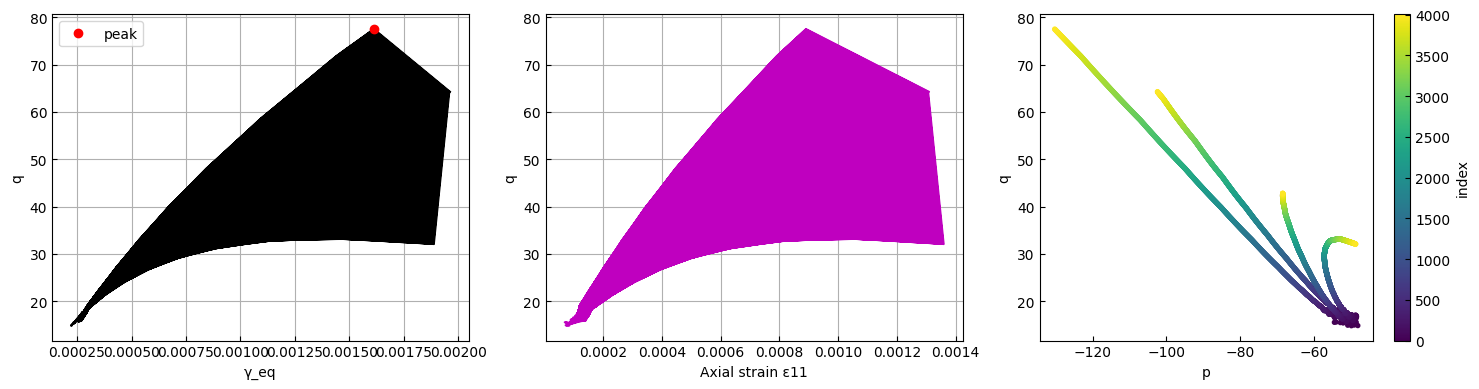

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

s11 = sigma11
s22 = sigma22
s33 = sigma33
s12 = sigma12

e11 = eps11
e22 = eps22
e12 = eps12

def trim_to_same_length(*arrays):
    arrays_np = [np.ravel(np.asarray(a)) for a in arrays]
    min_len = min(len(a) for a in arrays_np)
    return [a[:min_len] for a in arrays_np]


def compute_p_q(s11, s22, s33, s12):
    s11, s22, s33, s12 = trim_to_same_length(s11, s22, s33, s12)
    p = (s11 + s22 + s33) / 3.0
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12**2)
    q = np.sqrt(1.5 * s_dot_s)
    return p, q

def compute_gamma_eq(e11, e22, e33, e12):
    e11, e22, e33, e12 = trim_to_same_length(e11, e22, e33, e12)
    eps_v = e11 + e22 + e33
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (e12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq

def detect_peak_failure(q, gamma, drop_frac=0.1, lookahead=3):
    q = np.asarray(q).flatten()
    gamma = np.asarray(gamma).flatten()
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break
    return {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma) > peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma) > failure_idx) else None
    }


def plot_backbone(q, gamma, eps_axial=None, p=None, meta=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gamma, q, '-k', lw=1.5)
    if meta:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
        axes[0].legend()
    axes[0].set_xlabel('γ_eq')
    axes[0].set_ylabel('q')
    axes[0].grid(True)
    if eps_axial is not None:
        eps_axial, q_ax = trim_to_same_length(eps_axial, q)
        axes[1].plot(eps_axial, q_ax, '-m')
        axes[1].set_xlabel('Axial strain ε11')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')
    if p is not None:
        p, q_p = trim_to_same_length(p, q)
        sc = axes[2].scatter(p, q_p, c=np.arange(len(q_p)), cmap='viridis', s=8)
        axes[2].set_xlabel('p')
        axes[2].set_ylabel('q')
        plt.colorbar(sc, ax=axes[2], label='index')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    e33 = -(e11 + e22)
    p, q = compute_p_q(s11, s22, s33, s12)
    eps_v, gamma = compute_gamma_eq(e11, e22, e33, e12)
    meta = detect_peak_failure(q, gamma)
    plot_backbone(q, gamma, eps_axial=e12, p=p,meta=meta ) #meta=meta
